## Load Dataset

In [14]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/delivery_data.csv")

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


###  Basic Data Understanding

In [2]:
df.shape


(45584, 20)

In [3]:
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weather_conditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken (min)']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [5]:
df.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weather_conditions              616
Road_traffic_density            601
Festival                        228
ID                                0
Delivery_person_ID                0
Restaurant_latitude               0
Restaurant_longitude              0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_latitude        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Time_taken (min)"].describe()

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64

In [8]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique()[:20])


ID:
<StringArray>
['0xcdcd', '0xd987', '0x2784', '0xc8b6', '0xdb64', '0x3af3', '0x3aab',
 '0x689b', '0x6f67', '0xc9cf', '0x36b8', '0x5795', '0x6c6b', '0xb816',
 '0x539b', '0xa1b2', '0x3231', '0x8bc0', '0x2288', '0x3c5e']
Length: 20, dtype: str

Delivery_person_ID:
<StringArray>
[   'DEHRES17DEL01',    'KOCRES16DEL01',   'PUNERES13DEL03',
   'LUDHRES15DEL02',    'KNPRES14DEL02',    'MUMRES15DEL03',
    'MYSRES01DEL01',   'PUNERES20DEL01',    'HYDRES14DEL01',
    'KOLRES15DEL03',   'PUNERES19DEL02', 'RANCHIRES06DEL02',
  'COIMBRES13DEL01',   'CHENRES19DEL02',    'MUMRES02DEL01',
   'CHENRES01DEL01',    'JAPRES16DEL03',    'SURRES15DEL03',
   'BANGRES09DEL03',   'PUNERES04DEL01']
Length: 20, dtype: str

Order_Date:
<StringArray>
['12-02-2022', '13-02-2022', '04-03-2022', '14-02-2022', '02-04-2022',
 '01-03-2022', '16-03-2022', '20-03-2022', '15-02-2022', '10-03-2022',
 '11-03-2022', '27-03-2022', '26-03-2022', '05-04-2022', '12-03-2022',
 '01-04-2022', '05-03-2022', '11-02-2022', '08-03-

C:\Users\saura\AppData\Local\Temp\ipykernel_11472\4223941946.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,45584,45584,0xcdcd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,45584,1320,JAPRES11DEL02,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,43730.0,NaN,NaN,NaN,29.566911,5.815064,15.0,25.0,30.0,35.0,50.0
Delivery_person_Ratings,43676.0,NaN,NaN,NaN,4.633774,0.334744,1.0,4.5,4.7,4.9,6.0
Restaurant_latitude,45584.0,NaN,NaN,NaN,17.017948,8.185674,-30.905562,12.933284,18.55144,22.728163,30.914057
Restaurant_longitude,45584.0,NaN,NaN,NaN,70.229684,22.885575,-88.366217,73.17,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,NaN,NaN,NaN,17.46548,7.335562,0.01,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,NaN,NaN,NaN,70.844161,21.120578,0.01,73.28,76.002574,78.107044,88.563452
Order_Date,45584,44,15-03-2022,1192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_Orderd,43853,176,21:55,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
for col in df.select_dtypes(include="object").columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(15))
    


 ID
ID
0xcdcd    1
0xd987    1
0x2784    1
0xc8b6    1
0xdb64    1
0x3af3    1
0x3aab    1
0x689b    1
0x6f67    1
0xc9cf    1
0x36b8    1
0x5795    1
0x6c6b    1
0xb816    1
0x539b    1
Name: count, dtype: int64

 Delivery_person_ID
Delivery_person_ID
JAPRES11DEL02       67
PUNERES01DEL01      67
RANCHIRES02DEL01    66
VADRES11DEL02       66
JAPRES03DEL01       66
HYDRES04DEL02       66
VADRES08DEL02       66
SURRES11DEL01       65
INDORES08DEL02      65
VADRES11DEL01       65
VADRES14DEL01       65
BANGRES07DEL02      65
RANCHIRES02DEL02    65
INDORES15DEL01      65
JAPRES09DEL02       65
Name: count, dtype: int64

 Order_Date
Order_Date
15-03-2022    1192
03-04-2022    1178
13-03-2022    1169
26-03-2022    1165
24-03-2022    1162
09-03-2022    1159
05-04-2022    1156
05-03-2022    1154
07-03-2022    1153
03-03-2022    1150
21-03-2022    1149
11-03-2022    1148
19-03-2022    1148
30-03-2022    1141
01-03-2022    1140
Name: count, dtype: int64

 Time_Orderd
Time_Orderd
NaN           

C:\Users\saura\AppData\Local\Temp\ipykernel_11472\3549657600.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [11]:
df.select_dtypes(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
Delivery_person_Ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
Restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
Restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken (min),45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


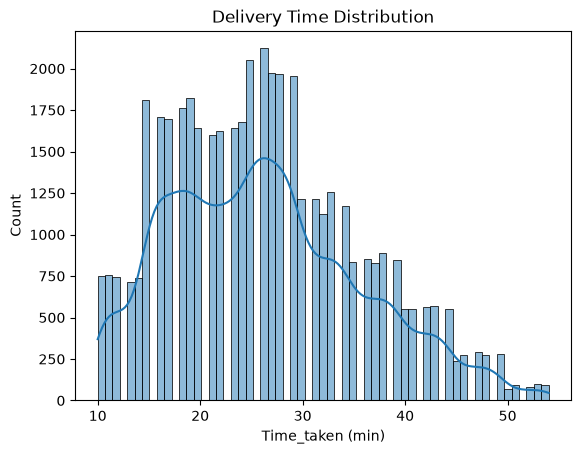

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Time_taken (min)"], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

### Unique Value Analysis

In [13]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))


ID
ID
0xcdcd    1
0xd987    1
0x2784    1
0xc8b6    1
0xdb64    1
0x3af3    1
0x3aab    1
0x689b    1
0x6f67    1
0xc9cf    1
Name: count, dtype: int64

Delivery_person_ID
Delivery_person_ID
JAPRES11DEL02       67
PUNERES01DEL01      67
RANCHIRES02DEL01    66
VADRES11DEL02       66
JAPRES03DEL01       66
HYDRES04DEL02       66
VADRES08DEL02       66
SURRES11DEL01       65
INDORES08DEL02      65
VADRES11DEL01       65
Name: count, dtype: int64

Order_Date
Order_Date
15-03-2022    1192
03-04-2022    1178
13-03-2022    1169
26-03-2022    1165
24-03-2022    1162
09-03-2022    1159
05-04-2022    1156
05-03-2022    1154
07-03-2022    1153
03-03-2022    1150
Name: count, dtype: int64

Time_Orderd
Time_Orderd
NaN            1731
21:55           461
17:55           456
0.833333333     449
22:20           448
21:35           446
19:50           444
21:15           442
22:45           438
21:20           437
Name: count, dtype: int64

Time_Order_picked
Time_Order_picked
21:30    495
22:50    474

C:\Users\saura\AppData\Local\Temp\ipykernel_11472\3067452835.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


### Missing Value Handling

In [7]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weather_conditions              616
Road_traffic_density            601
Festival                        228
ID                                0
Delivery_person_ID                0
Restaurant_latitude               0
Restaurant_longitude              0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_latitude        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken (min)                  0
dtype: int64

In [6]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Delivery_person_Ratings        4.185679
Delivery_person_Age            4.067217
Time_Orderd                    3.797385
City                           2.632503
multiple_deliveries            2.178396
Weather_conditions             1.351351
Road_traffic_density           1.318445
Festival                       0.500176
ID                             0.000000
Delivery_person_ID             0.000000
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Time_Order_picked              0.000000
Order_Date                     0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Type_of_vehicle                0.000000
Type_of_order                  0.000000
Vehicle_condition              0.000000
Time_taken (min)               0.000000
dtype: float64

In [8]:
# Handle missing values

df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

df["multiple_deliveries"] = df["multiple_deliveries"].fillna(
    df["multiple_deliveries"].mode()[0]
)

df["Weather_conditions"] = df["Weather_conditions"].fillna(
    df["Weather_conditions"].mode()[0]
)

df["Road_traffic_density"] = df["Road_traffic_density"].fillna(
    df["Road_traffic_density"].mode()[0]
)

df["Festival"] = df["Festival"].fillna(
    df["Festival"].mode()[0]
)

df["City"] = df["City"].fillna(
    df["City"].mode()[0]
)

df["Time_Orderd"] = df["Time_Orderd"].fillna(
    df["Time_Orderd"].mode()[0]
)

In [9]:
# Check remaining missing values

df.isnull().sum().sort_values(ascending=False)

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
dtype: int64

### Data Cleaning

In [15]:
# Check invalid age and ratings

print("Age < 18:", (df["Delivery_person_Age"] < 18).sum())
print("Rating > 5:", (df["Delivery_person_Ratings"] > 5).sum())


Age < 18: 38
Rating > 5: 53


In [16]:
# Replace invalid values with missing values

df.loc[df["Delivery_person_Age"] < 18, "Delivery_person_Age"] = np.nan
df.loc[df["Delivery_person_Ratings"] > 5, "Delivery_person_Ratings"] = np.nan

In [17]:
# Fill newly created missing values

df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

In [18]:
# Verify cleaning

print(df["Delivery_person_Age"].min())
print(df["Delivery_person_Ratings"].max())

20.0
5.0


### Exploratory Data Analysis
#### Delivery Time Distribution

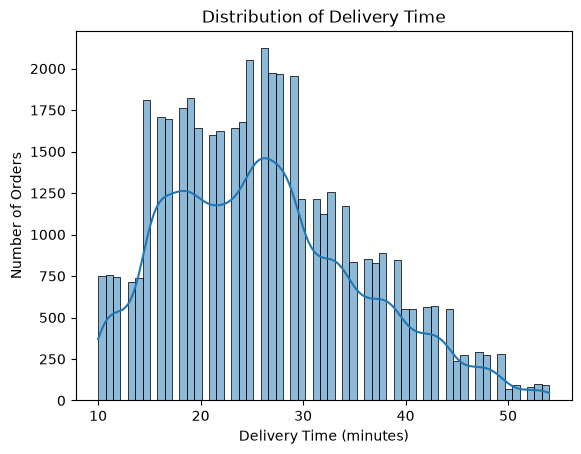

In [19]:
# Distribution of delivery time

sns.histplot(df["Time_taken (min)"], kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.show()

#### Traffic vs Delivery Time

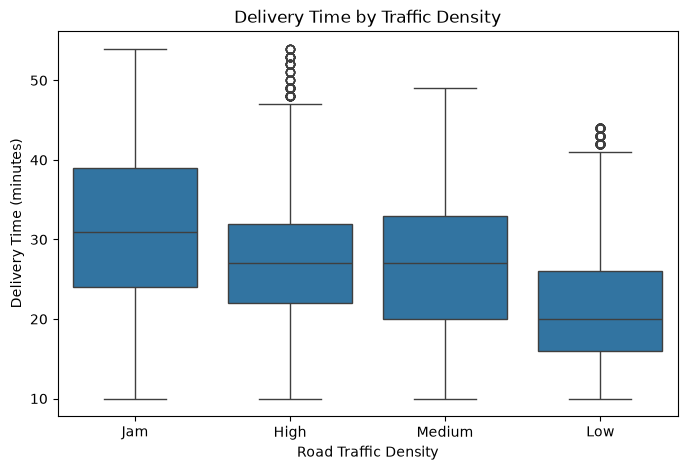

In [20]:
# Compare delivery time across traffic conditions

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Road_traffic_density", y="Time_taken (min)")
plt.title("Delivery Time by Traffic Density")
plt.xlabel("Road Traffic Density")
plt.ylabel("Delivery Time (minutes)")
plt.show()

#### Weather vs Delivery Time

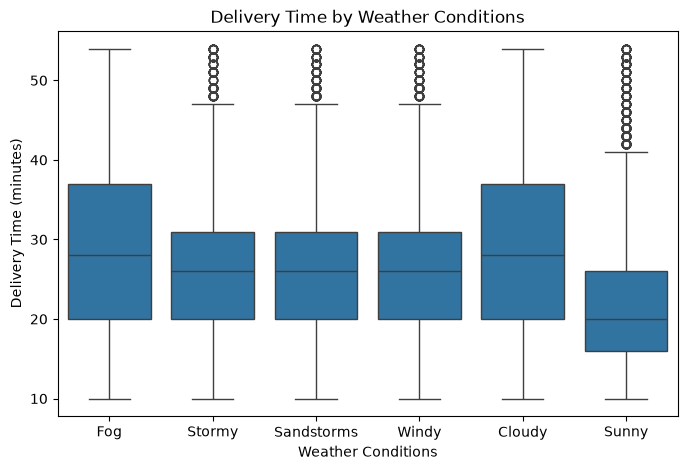

In [21]:
# Compare delivery time across weather conditions

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Weather_conditions", y="Time_taken (min)")
plt.title("Delivery Time by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Delivery Time (minutes)")
plt.show()

#### Vehicle Type vs Delivery Time

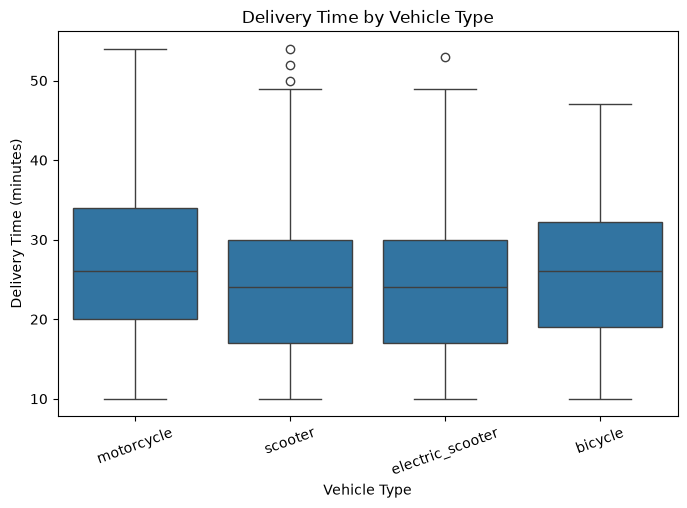

In [22]:
# Compare delivery time across vehicle types

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Type_of_vehicle", y="Time_taken (min)")
plt.title("Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=20)
plt.show()

#### Order Type vs Delivery Time

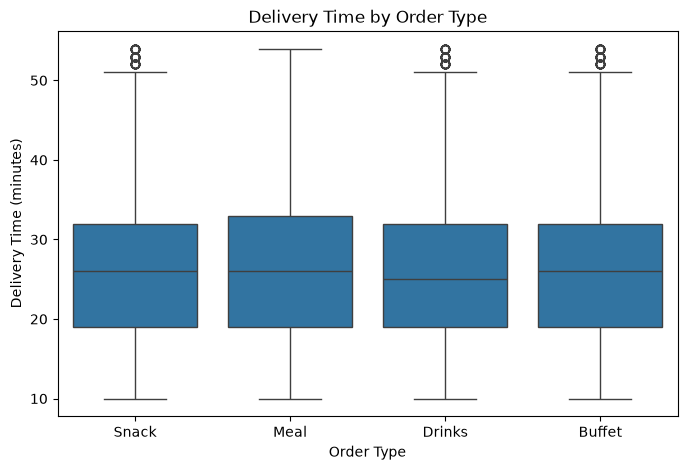

In [23]:
# Compare delivery time across order types

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Type_of_order", y="Time_taken (min)")
plt.title("Delivery Time by Order Type")
plt.xlabel("Order Type")
plt.ylabel("Delivery Time (minutes)")
plt.show()

#### City vs Delivery Time

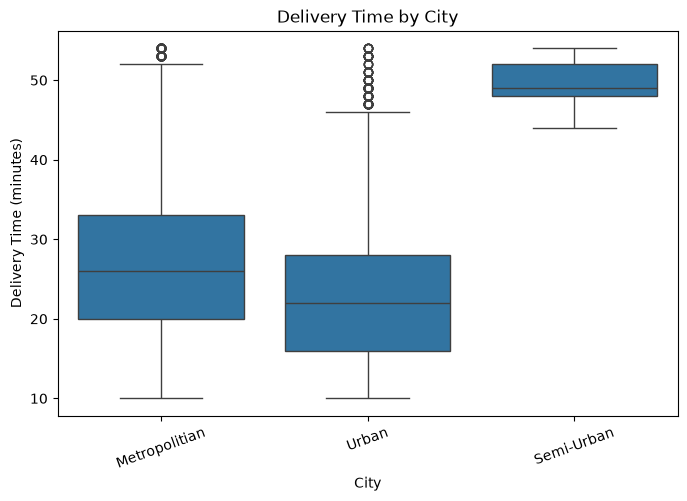

In [24]:
# Compare delivery time across cities

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="City", y="Time_taken (min)")
plt.title("Delivery Time by City")
plt.xlabel("City")
plt.ylabel("Delivery Time (minutes)")
plt.xticks(rotation=20)
plt.show()

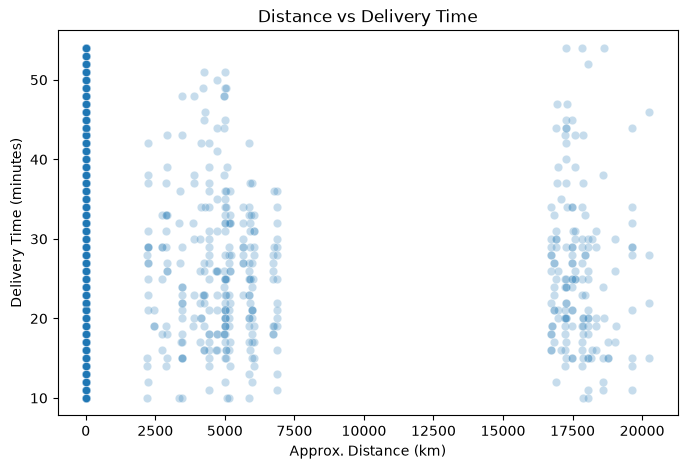

In [25]:
# Check relationship between delivery distance and time

import numpy as np

distance = 111 * np.sqrt(
    (df["Delivery_location_latitude"] - df["Restaurant_latitude"])**2 +
    (df["Delivery_location_longitude"] - df["Restaurant_longitude"])**2
)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=distance, y=df["Time_taken (min)"], alpha=0.25)
plt.title("Distance vs Delivery Time")
plt.xlabel("Approx. Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

#### Correlation Analysis

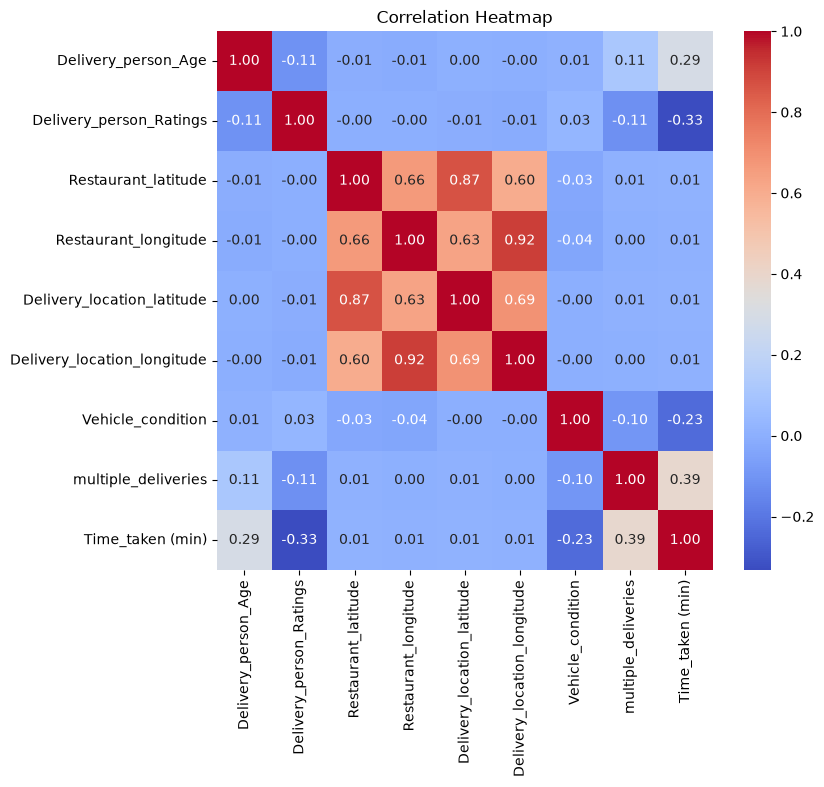

In [27]:
# Check correlation among numeric features

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()